# 🧬 AlphaGenome Tools Example

This notebook demonstrates how to run **AlphaGenome** for genomic interval prediction, variant-effect prediction, variant scoring, interval scoring, and in-silico mutagenesis.

Examples reproduce figures from the [AlphaGenome paper](https://www.nature.com/articles/s41586-025-10014-0) and [quick-start notebook](https://colab.research.google.com/github/google-deepmind/alphagenome_research/blob/main/colabs/quick_start.ipynb).

## 📖 What is AlphaGenome?

[AlphaGenome](https://github.com/google-deepmind/alphagenome_research) is a multi-task genomic foundation model from Google DeepMind that predicts regulatory signals, splicing, and 3D contact maps from DNA sequence at single base-pair resolution.

### Key Features:
- **Interval prediction** -- Predict regulatory outputs (ATAC, CAGE, RNA-seq, etc.) over a genomic region
- **Variant-effect prediction** -- Compare reference vs alternate allele predictions
- **Variant scoring** -- Score variants with recommended variant scorers (tidy DataFrame output)
- **Interval scoring** -- Score intervals with recommended interval scorers
- **In-silico mutagenesis** -- Saturate-mutate a sub-interval and score each mutation
- **Isolated runtime** -- Runs in a standalone `ToolInstance` venv with JAX + GPU

### Supported context lengths:
- **1,048,576 bp** (1 Mb -- recommended)
- **524,288 bp** (500 Kb)
- **131,072 bp** (100 Kb)
- **16,384 bp** (16 Kb)

Interval-based tools auto-resize to the nearest supported length if needed. Raw sequence inputs must already match a supported length.

## 📥 Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

from bio_programming_tools import (
    AlphaGenomeInterval,
    AlphaGenomeVariant,
    AlphaGenomeISM,
    AlphaGenomePredictIntervalsInput,
    AlphaGenomePredictVariantsInput,
    AlphaGenomePredictSequencesInput,
    AlphaGenomeScoreVariantsInput,
    AlphaGenomeScoreIntervalsInput,
    AlphaGenomeScoreISMInput,
    AlphaGenomePredictIntervalsConfig,
    AlphaGenomePredictVariantsConfig,
    AlphaGenomePredictSequencesConfig,
    AlphaGenomeScoreVariantsConfig,
    AlphaGenomeScoreIntervalsConfig,
    AlphaGenomeScoreISMConfig,
    run_alphagenome_predict_intervals,
    run_alphagenome_predict_variants,
    run_alphagenome_predict_sequences,
    run_alphagenome_score_variants,
    run_alphagenome_score_intervals,
    run_alphagenome_score_ism_variants_batch,
)

## 🎨 Plotting helper

A small utility to plot serialized AlphaGenome track predictions.

Our tools return predictions as JSON-serialized dicts (not native `TrackData` objects), so we use `matplotlib` directly rather than the upstream `plot_components` from alphagenome.

In [2]:
# Use a clean plot style
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.family": "sans-serif",
})


def plot_tracks(
    predictions: dict,
    track_keys: list[str],
    output_start: int,
    output_end: int,
    chromosome: str = "",
    colors: list[str] | None = None,
    labels: list[str] | None = None,
    filled: list[bool] | None = None,
    fig_width: float = 14,
    track_height: float = 2.5,
    title: str | None = None,
):
    """Plot one or more serialized AlphaGenome track predictions."""
    n = len(track_keys)
    if colors is None:
        cmap = plt.colormaps["viridis"]
        colors = [mcolors.rgb2hex(cmap(i)) for i in np.linspace(0.15, 0.85, n)]
    if labels is None:
        labels = [k.upper().replace("_", " ") for k in track_keys]
    if filled is None:
        filled = [True] * n

    fig, axes = plt.subplots(
        n, 1, figsize=(fig_width, track_height * n), sharex=True, squeeze=False
    )

    for idx, (ax, key, color, label, fill) in enumerate(
        zip(axes[:, 0], track_keys, colors, labels, filled)
    ):
        track_data = predictions.get(key)
        if track_data is None:
            ax.text(0.5, 0.5, f"{label} — not available",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="grey", style="italic")
            ax.set_ylabel(label)
            continue

        values = np.array(track_data["values"])
        signal = values.mean(axis=-1) if values.ndim == 2 else values
        bp = np.linspace(output_start, output_end, len(signal))

        if fill:
            ax.fill_between(bp, signal, alpha=0.55, color=color, linewidth=0)
            ax.plot(bp, signal, color=color, linewidth=0.6, alpha=0.85)
        else:
            ax.plot(bp, signal, color=color, linewidth=0.7, alpha=0.9)
        ax.set_ylabel(label)
        ax.set_xlim(output_start, output_end)

    region = f"{chromosome}:{output_start:,}-{output_end:,}" if chromosome else ""
    axes[-1, 0].set_xlabel(f"Genomic position (bp)\n{region}")
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()


def plot_variant_overlay(
    variant_result,
    requested_outputs: list[str],
    ref_color: str = "dimgrey",
    alt_color: str = "red",
    fig_width: float = 14,
    track_height: float = 3.0,
    title: str | None = None,
):
    """Plot overlaid REF vs ALT predictions for a variant-effect result."""
    variant_preds = variant_result.result.get("predictions", {})
    ref_preds = variant_preds.get("reference", {})
    alt_preds = variant_preds.get("alternate", {})
    variant_pos = variant_result.variant["position"]
    output_start = variant_result.interval_start
    output_end = variant_result.interval_end

    n = len(requested_outputs)
    fig, axes = plt.subplots(
        n, 1, figsize=(fig_width, track_height * n), sharex=True, squeeze=False
    )

    for ax, output_name in zip(axes[:, 0], requested_outputs):
        track_key = output_name.lower()
        ref_data = ref_preds.get(track_key)
        alt_data = alt_preds.get(track_key)
        if ref_data is None or alt_data is None:
            ax.text(0.5, 0.5, f"{output_name} — not available",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="grey", style="italic")
            ax.set_ylabel(output_name.replace("_", " "))
            continue

        ref_vals = np.array(ref_data["values"])
        alt_vals = np.array(alt_data["values"])
        ref_signal = ref_vals.mean(axis=-1) if ref_vals.ndim == 2 else ref_vals
        alt_signal = alt_vals.mean(axis=-1) if alt_vals.ndim == 2 else alt_vals

        bp = np.linspace(output_start, output_end, len(ref_signal))
        ax.plot(bp, ref_signal, color=ref_color, alpha=0.85, linewidth=0.7, label="REF")
        ax.plot(bp, alt_signal, color=alt_color, alpha=0.75, linewidth=0.7, label="ALT")
        ax.axvline(
            variant_pos, color="#333333", linestyle="--", alpha=0.5,
            linewidth=1.0, label="Variant",
        )
        ax.legend(loc="upper right", fontsize=8, framealpha=0.8, edgecolor="none")
        ax.set_ylabel(output_name.replace("_", " "))
        ax.set_xlim(output_start, output_end)

    region = f"{variant_result.chromosome}:{output_start:,}-{output_end:,}"
    axes[-1, 0].set_xlabel(f"Genomic position (bp)\n{region}")
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

---
## 🧪 1. Interval Prediction (Figure 2a)

Reproduces **Figure 2a** from the AlphaGenome paper: multi-track predictions within a **1 Mb** region of human chromosome 19 (`chr19:10,587,331–11,635,907`) in the **HepG2** cell line.

### API Reference

**`AlphaGenomePredictIntervalsInput`**

| Field | Type | Description |
|-------|------|-------------|
| `intervals` | `List[AlphaGenomeInterval]` | Genomic intervals (single auto-wrapped) |

**`AlphaGenomeInterval`**

| Field | Type | Description |
|-------|------|-------------|
| `chromosome` | `str` | Chromosome identifier, e.g. `"chr1"` |
| `interval_start` | `int` | Interval start (0-based, inclusive) |
| `interval_end` | `int` | Interval end (0-based, exclusive) |

**`AlphaGenomePredictIntervalsConfig`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `requested_outputs` | `List[OutputTypeName]` | *(required)* | Output type names to predict (e.g. `ATAC`, `CAGE`, `DNASE`, `RNA_SEQ`, `CHIP_HISTONE`, `CHIP_TF`, `SPLICE_SITES`, `SPLICE_SITE_USAGE`, `SPLICE_JUNCTIONS`, `CONTACT_MAPS`, `PROCAP`) |
| `ontology_terms` | `Optional[List[str]]` | `None` | Optional ontology term filters (e.g. `"EFO:0001187"` for HepG2) |
| `organism` | `Literal["human", "mouse"]` | `"human"` | Organism for predictions |
| `model_version` | `str` | `"all_folds"` | AlphaGenome Hugging Face model version |

**`AlphaGenomePredictIntervalsOutput`**

| Field | Type | Description |
|-------|------|-------------|
| `results` | `List[AlphaGenomePredictOutput]` | Per-interval prediction outputs (supports indexing/iteration) |

In [3]:
# Paper Figure 2a coordinates — chr19, 1 Mb window, HepG2 cell line
interval_inputs = AlphaGenomePredictIntervalsInput(
    intervals=AlphaGenomeInterval(
        chromosome="chr19",
        interval_start=10_587_331,
        interval_end=11_635_907,
    ),
)

interval_config = AlphaGenomePredictIntervalsConfig(
    requested_outputs=["RNA_SEQ", "ATAC", "DNASE", "CHIP_HISTONE", "CHIP_TF"],
    ontology_terms=["EFO:0001187"],  # HepG2
    organism="human",
)

interval_result = run_alphagenome_predict_intervals(interval_inputs, interval_config)
output = interval_result[0]
print("Requested outputs:", output.requested_outputs)
print("Result keys:", list(output.result.get("predictions", {}).keys()))

Requested outputs: ['RNA_SEQ', 'ATAC', 'DNASE', 'CHIP_HISTONE', 'CHIP_TF']
Result keys: ['atac', 'cage', 'dnase', 'rna_seq', 'chip_histone', 'chip_tf', 'splice_sites', 'splice_site_usage', 'splice_junctions', 'contact_maps', 'procap']


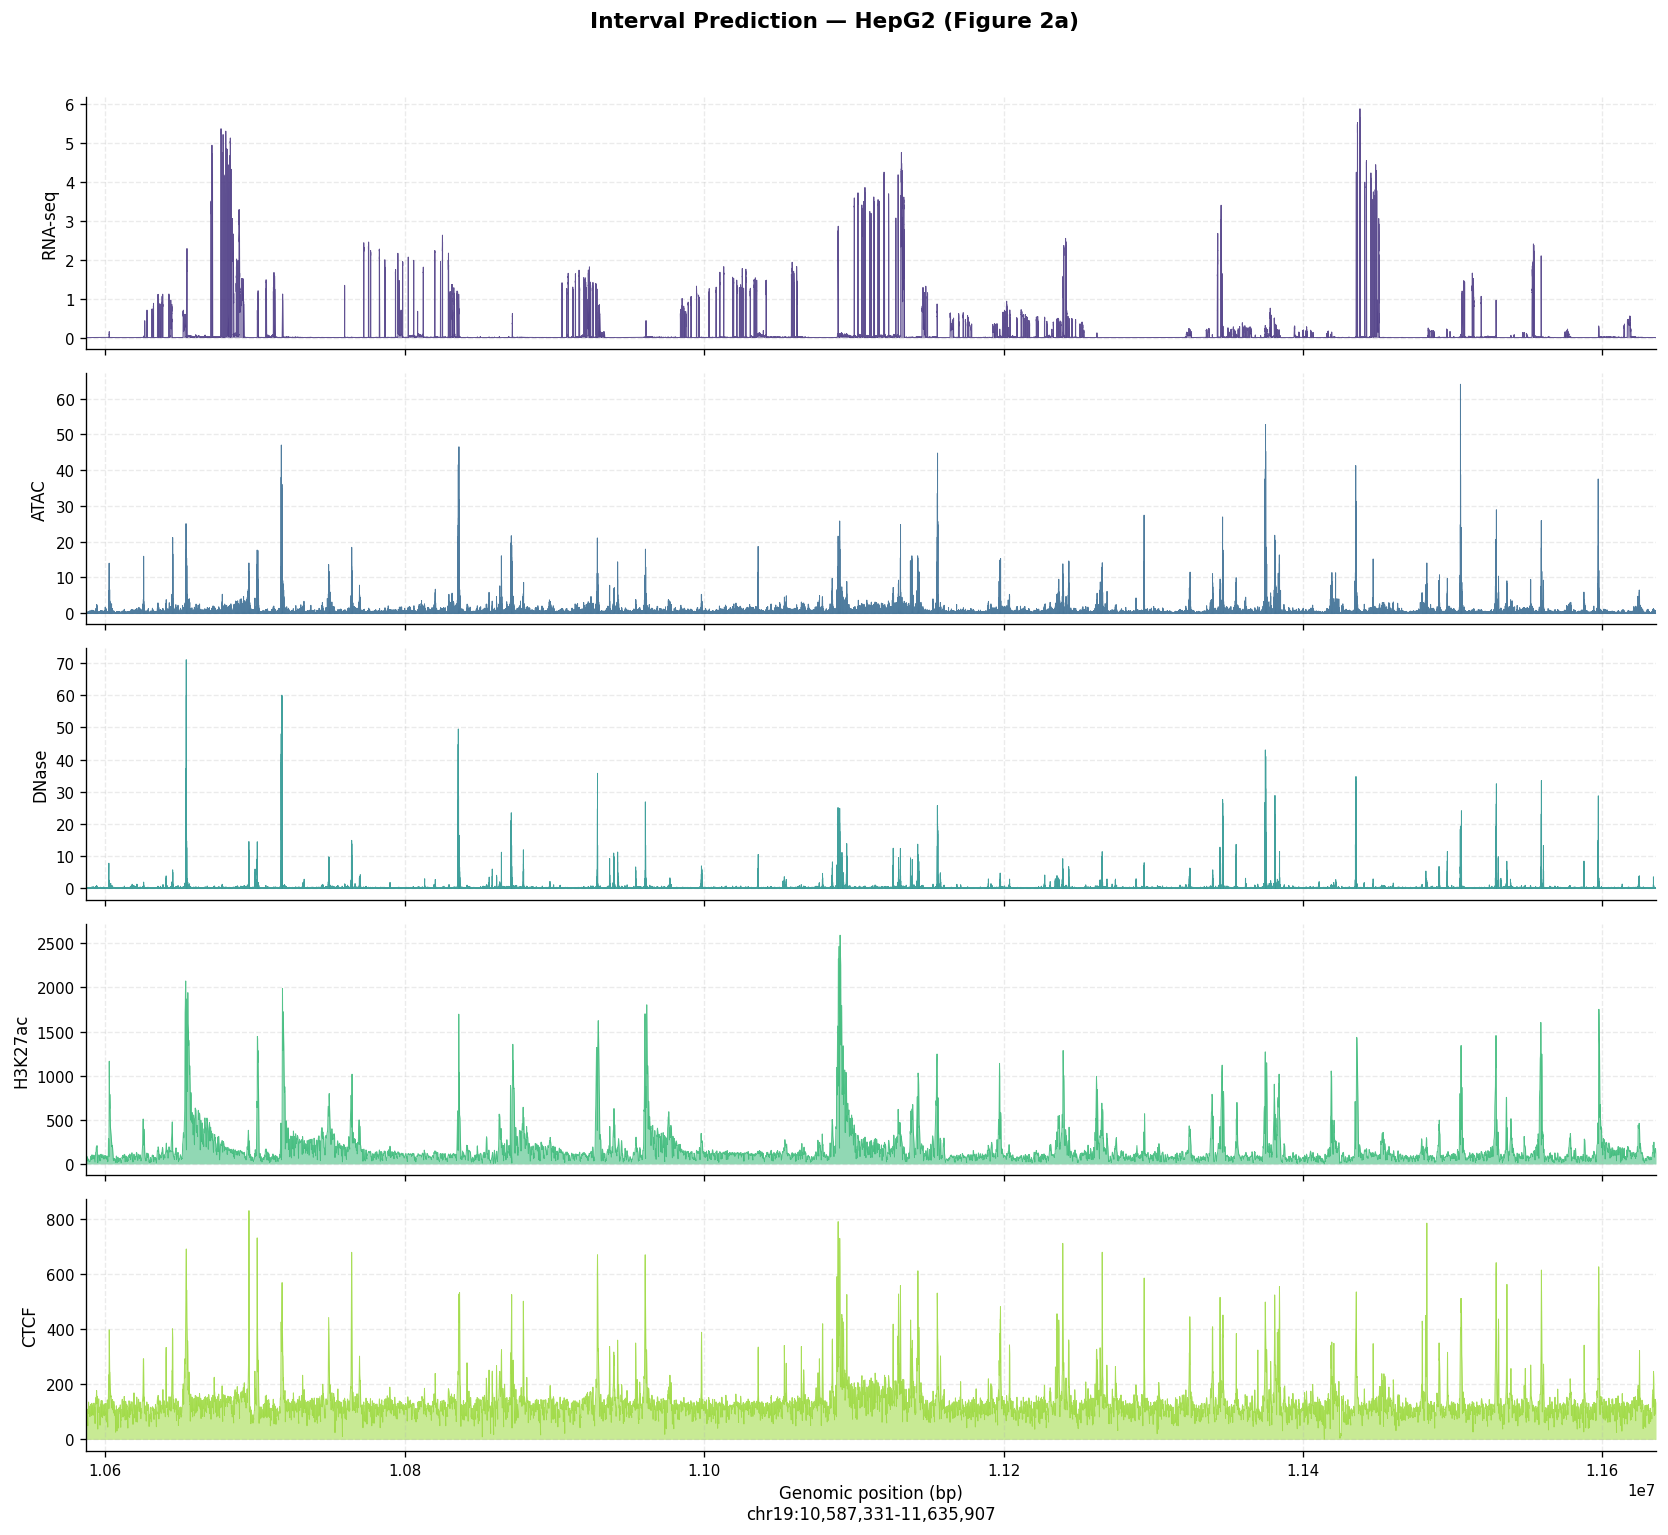

In [4]:
# 📈 Plot interval predictions — reproducing Figure 2a layout
output = interval_result[0]
plot_tracks(
    predictions=output.result.get("predictions", {}),
    track_keys=["rna_seq", "atac", "dnase", "chip_histone", "chip_tf"],
    output_start=output.interval_start,
    output_end=output.interval_end,
    chromosome=output.chromosome,
    labels=["RNA-seq", "ATAC", "DNase", "H3K27ac", "CTCF"],
    filled=[True, True, True, True, True],
    title="Interval Prediction — HepG2 (Figure 2a)",
)

---
## 🧬 2. Variant-Effect Prediction (Figure 3c)

Reproduces **Figure 3c** from the AlphaGenome paper: a variant in the *COL6A2* gene (`chr21:46,126,238 G>C`) that causes alternative splice junction formation by creating a new splicing donor and disrupting the extant one.

Predictions use a **1 Mb** context centered on the variant, with tracks filtered to **Aorta** tissue (`UBERON:0001496`). The plot overlays reference (**REF**, skyblue) and alternate (**ALT**, red) predictions for RNA-seq and splice-site usage, with a dashed line marking the variant position.

### API Reference

**`AlphaGenomePredictVariantsInput`**

| Field | Type | Description |
|-------|------|-------------|
| `variants` | `List[AlphaGenomeVariant]` | Variants with interval context (single auto-wrapped) |

**`AlphaGenomeVariant`**

| Field | Type | Description |
|-------|------|-------------|
| `chromosome` | `str` | Chromosome identifier, e.g. `"chr1"` |
| `interval_start` | `int` | Interval start (0-based, inclusive) |
| `interval_end` | `int` | Interval end (0-based, exclusive) |
| `variant_position` | `int` | Variant genomic position (0-based) |
| `reference_bases` | `str` | Reference allele, e.g. `"A"` or `"AC"` |
| `alternate_bases` | `str` | Alternate allele, e.g. `"G"` or `"GTT"` |

**`AlphaGenomePredictVariantsConfig`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `requested_outputs` | `List[OutputTypeName]` | *(required)* | Output type names to predict |
| `ontology_terms` | `Optional[List[str]]` | `None` | Optional ontology term filters |
| `organism` | `Literal["human", "mouse"]` | `"human"` | Organism for predictions |
| `model_version` | `str` | `"all_folds"` | AlphaGenome Hugging Face model version |

In [5]:
# Paper Figure 3c coordinates — chr21:46,126,238 G>C (COL6A2), 1 Mb context, Aorta tissue
variant_inputs = AlphaGenomePredictVariantsInput(
    variants=AlphaGenomeVariant(
        chromosome="chr21",
        interval_start=45_601_950,
        interval_end=46_650_526,
        variant_position=46_126_238,
        reference_bases="G",
        alternate_bases="C",
    ),
)

variant_config = AlphaGenomePredictVariantsConfig(
    requested_outputs=["RNA_SEQ", "SPLICE_SITE_USAGE"],
    ontology_terms=["UBERON:0001496"],  # Aorta
    organism="human",
)

variant_result = run_alphagenome_predict_variants(variant_inputs, variant_config)
output = variant_result[0]
print("Variant metadata:", output.variant)
print("Result keys:", list(output.result.get("predictions", {}).keys()))

Variant metadata: {'position': 46126238, 'reference_bases': 'G', 'alternate_bases': 'C'}
Result keys: ['reference', 'alternate']


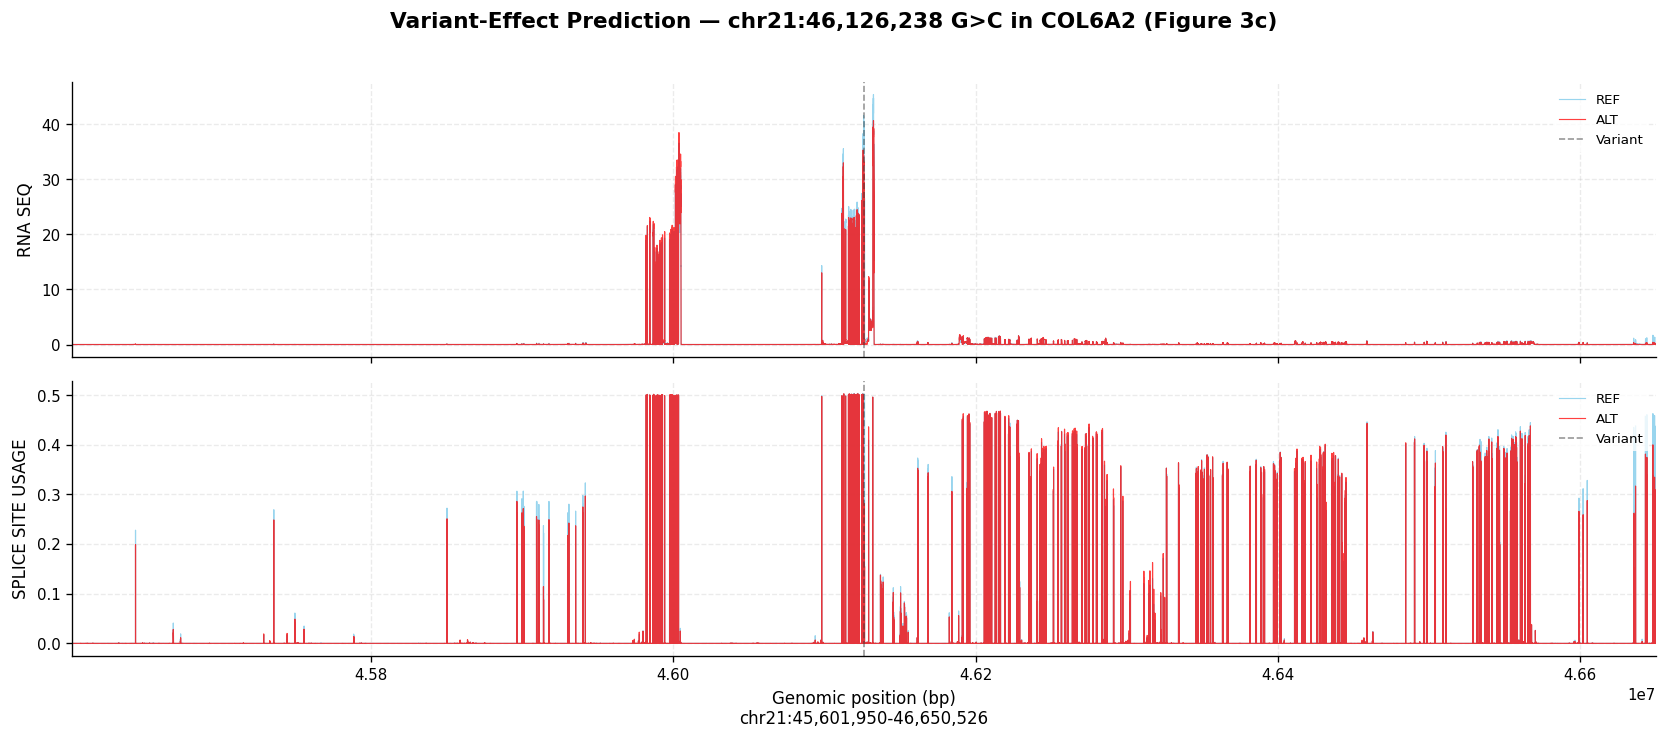

In [6]:
# 📈 Plot variant-effect predictions — reproducing Figure 3c layout (REF vs ALT)
# Zoom into a 1.5 kb window around the variant (matching the paper figure)
plot_variant_overlay(
    variant_result[0],
    requested_outputs=variant_config.requested_outputs,
    ref_color="skyblue",
    alt_color="red",
    title="Variant-Effect Prediction — chr21:46,126,238 G>C in COL6A2 (Figure 3c)",
)

---
## 🔡 3. Raw Sequence Prediction

Run predictions from a raw DNA string (no reference genome lookup). The sequence length must match a supported context length. A single string is auto-wrapped into a list.

### API Reference

**`AlphaGenomePredictSequencesInput`**

| Field | Type | Description |
|-------|------|-------------|
| `sequences` | `List[str]` | Raw DNA sequences for prediction (single string auto-wrapped) |

**`AlphaGenomePredictSequencesConfig`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `requested_outputs` | `List[OutputTypeName]` | *(required)* | Output type names to predict |
| `ontology_terms` | `Optional[List[str]]` | `None` | Optional ontology term filters |
| `organism` | `Literal["human", "mouse"]` | `"human"` | Organism for predictions |
| `model_version` | `str` | `"all_folds"` | AlphaGenome Hugging Face model version |

In [7]:
# 2,048 bp from the APOE gene locus on chr19 (hg38: chr19:44,905,791-44,907,839).
# The raw-sequence tool requires supported AlphaGenome context lengths, so we tile to 16,384 bp.
apoe_seq_2kb = (
    "AGTCCTACTCAGCCCCAGCGGAGGTGAAGGACGTCCTTCCCCAGGAGCCGGTGAGAAGCGCAGTCGGGGGCACGGGGATGA"
    "GCTCAGGGGCCTCTAGAAAGAGCTGGGACCCTGGGAACCCCTGGCCTCCAGGTAGTCTCAGGAGAGCTACTCGGGGTCGGG"
    "CTTGGGGAGAGGAGGAGCGGGGGTGAGGCAAGCAGCAGGGGACTGGACCTGGGAAGGGCTGGGCAGCAGAGACGACCCGAC"
    "CCGCTAGAAGGTGGGGTGGGGAGAGCAGCTGGACTGGGATGTAAGCCATAGCAGGACTCCACGAGTTGTCACTATCATTTAT"
    "CGAGCACCTACTGGGTGTCCCCAGTGTCCTCAGATCTCCATAACTGGGGAGCCAGGGGCAGCGACACGGTAGCTAGCCGTCG"
    "ATTGGAGAACTTTAAAATGAGGACTGAATTAGCTCATAAATGGAACACGGCGCTTAACTGTGAGGTTGGAGCTTAGAATGTG"
    "AAGGGAGAATGAGGAATGCGAGACTGGGACTGAGATGGAACCGGCGGTGGGGAGGGGGTGGGGGGATGGAATTTGAACCCC"
    "GGGAGAGGAAGATGGAATTTTCTATGGAGGCCGACCTGGGGATGGGGAGATAAGAGAAGACCAGGAGGGAGTTAAATAGGGAA"
    "TGGGTTGGGGGCGGCTTGGTAAATGTGCTGGGATTAGGCTGTTGCAGATAATGCAACAAGGCTTGGAAGGCTAACCTGGGG"
    "TGAGGCCGGGTTGGGGCCGGGCTGGGGGTGGGAGGAGTCCTCACTGGCGGTTGATTGACAGTTTCTCCTTCCCCAGACTGGC"
    "CAATCACAGGCAGGAAGATGAAGGTTCTGTGGGCTGCGTTGCTGGTCACATTCCTGGCAGGTATGGGGGCGGGGCTTGCTC"
    "GGTTCCCCCCGCTCCTCCCCCTCTCATCCTCACCTCAACCTCCTGGCCCCATTCAGGCAGACCCTGGGCCCCCTCTTCTGAG"
    "GCTTCTGTGCTGCTTCCTGGCTCTGAACAGCGATTTGACGCTCTCTGGGCCTCGGTTTCCCCCATCCTTGAGATAGGAGTTA"
    "GAAGTTGTTTTGTTGTTGTTGTTTGTTGTTGTTGTTTTGTTTTTTTGAGATGAAGTCTCGCTCTGTCGCCCAGGCTGGAGT"
    "GCAGTGGCGGGATCTCGGCTCACTGCAAGCTCCGCCTCCCAGGTCCACGCCATTCTCCTGCCTCAGCCTCCCAAGTAGCTGG"
    "GACTACAGGCACATGCCACCACACCCGACTAACTTTTTTGTATTTTCAGTAGAGACGGGGTTTCACCATGTTGGCCAGGCTG"
    "GTCTGGAACTCCTGACCTCAGGTGATCTGCCCGTTTCGATCTCCCAAAGTGCTGGGATTACAGGCGTGAGCCACCGCACCTG"
    "GCTGGGAGTTAGAGGTTTCTAATGCATTGCAGGCAGATAGTGAATACCAGACACGGGGCAGCTGTGATCTTTATTCTCCATC"
    "ACCCCCACACAGCCCTGCCTGGGGCACACAAGGACACTCAATACATGCTTTTCCGCTGGGCGCGGTGGCTCACCCCTGTAAT"
    "CCCAGCACTTTGGGAGGCCAAGGTGGGAGGATCACTTGAGCCCAGGAGTTCAACACCAGCCTGGGCAACATAGTGAGACCCT"
    "GTCTCTACTAAAAATACAAAAATTAGCCAGGCATGGTGCCACACACCTGTGCTCTCAGCTACTCAGGAGGCTGAGGCAGGAG"
    "GATCGCTTGAGCCCAGAAGGTCAAGGTTGCAGTGAACCATGTTCAGGCCGCTGCACTCCAGCCTGGGTGACAGAGCAAGAC"
    "CCTGTTTATAAATACATAATGCTTTCCAAGTGATTAAACCGACTCCCCCCTCACCCTGCCCACCATGGCTCCAAAGAAGCATT"
    "TGTGGAGCACCTTCTGTGTGCCCCTAGGTACTAGATGCCTGGACGGGGTCAGAAGGACCCTGACCCACCTTGAACTTGTTCC"
    "ACACAGGATGCCAGGCCAAGGTGGAGCAAGCGGTGGAGACAGAGCCGGAGCCCGAGCTGCGCCAGCAGACCGAGTGGCAGAG"
    "CGGC"
)

apoe_seq = apoe_seq_2kb * (16_384 // len(apoe_seq_2kb))

seq_inputs = AlphaGenomePredictSequencesInput(sequences=[apoe_seq])
seq_config = AlphaGenomePredictSequencesConfig(
    requested_outputs=["ATAC", "DNASE"],
    organism="human",
)

seq_result = run_alphagenome_predict_sequences(seq_inputs, seq_config)
output = seq_result[0]
print("Interval:", output.interval_start, "-", output.interval_end)
print("Result keys:", list(output.result.get("predictions", {}).keys()))

Interval: 0 - 16384
Result keys: ['atac', 'cage', 'dnase', 'rna_seq', 'chip_histone', 'chip_tf', 'splice_sites', 'splice_site_usage', 'splice_junctions', 'contact_maps', 'procap']


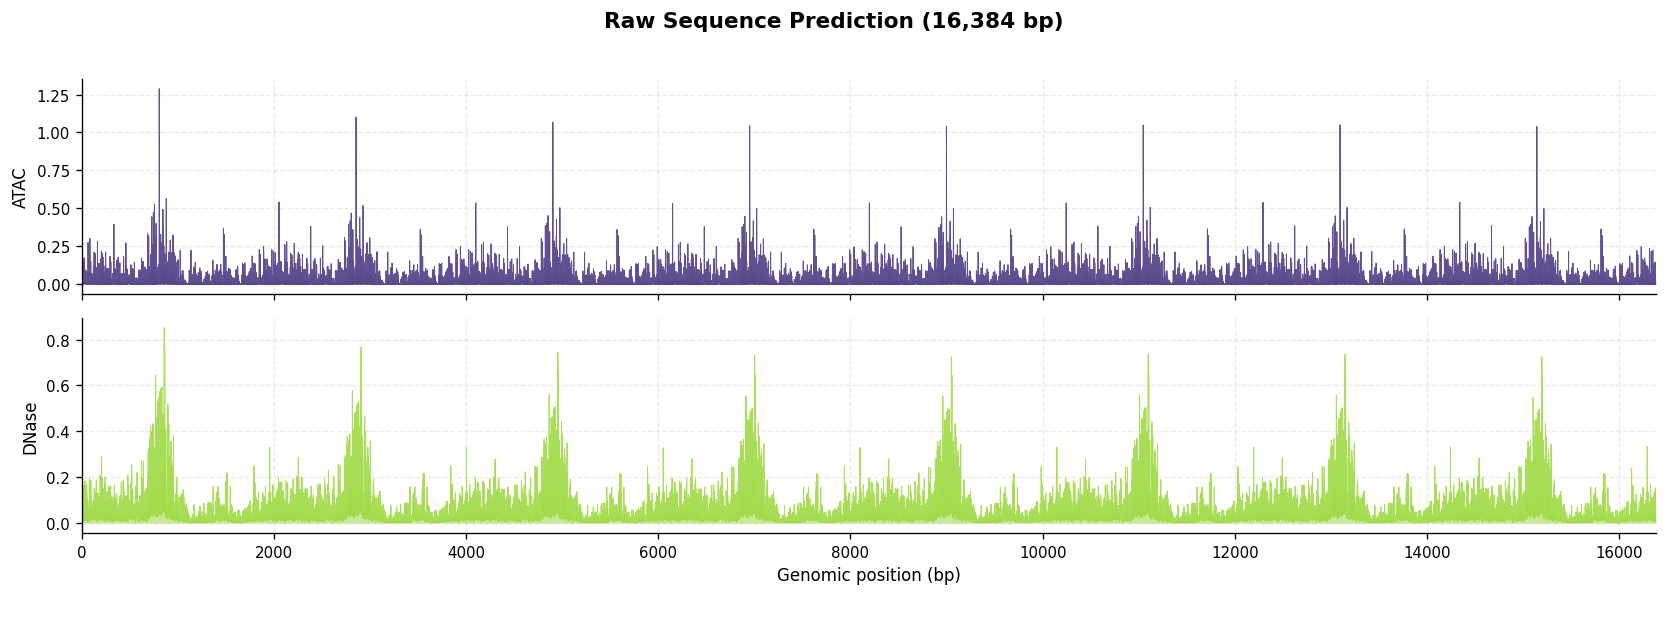

In [8]:
# 📈 Plot sequence predictions
output = seq_result[0]
plot_tracks(
    predictions=output.result.get("predictions", {}),
    track_keys=["atac", "dnase"],
    output_start=output.interval_start,
    output_end=output.interval_end,
    labels=["ATAC", "DNase"],
    title="Raw Sequence Prediction (16,384 bp)",
)

---
## 📏 4. Variant Scoring

Score a variant using AlphaGenome's recommended variant scorers. Returns a tidy table of scores (one row per scorer-track-gene combination).

Uses the same variant as **Figure 3c** (`chr21:46,126,238 G>C` in *COL6A2*).

### API Reference

**`AlphaGenomeScoreVariantsInput`**

| Field | Type | Description |
|-------|------|-------------|
| `variants` | `List[AlphaGenomeVariant]` | Variants with interval context (single auto-wrapped) |

**`AlphaGenomeVariant`** (see Section 2 above for full schema)

**`AlphaGenomeScoreVariantsConfig`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `variant_scorers` | `Optional[List[VariantScorerName]]` | `None` | Scorer names to use (e.g. `RNA_SEQ`, `ATAC`, `SPLICE_SITES`). `None` uses all recommended scorers. |
| `organism` | `Literal["human", "mouse"]` | `"human"` | Organism for predictions |
| `model_version` | `str` | `"all_folds"` | AlphaGenome Hugging Face model version |

**`AlphaGenomeScoreVariantsOutput`**

| Field | Type | Description |
|-------|------|-------------|
| `results` | `List[AlphaGenomeScoreOutput]` | Per-variant score outputs (supports indexing/iteration) |

Each `AlphaGenomeScoreOutput.scores` contains tidy records with keys such as `variant_id`, `scored_interval`, `gene_id`, `gene_name`, `output_type`, `variant_scorer`, `track_name`, `raw_score`, etc.

In [ ]:
score_variant_inputs = AlphaGenomeScoreVariantsInput(
    variants=AlphaGenomeVariant(
        chromosome="chr21",
        interval_start=45_601_950,
        interval_end=46_650_526,
        variant_position=46_126_238,
        reference_bases="G",
        alternate_bases="C",
    ),
)

score_variant_config = AlphaGenomeScoreVariantsConfig(
    variant_scorers=["RNA_SEQ", "SPLICE_SITES"],
    organism="human",
)

score_variant_result = run_alphagenome_score_variants(
    score_variant_inputs, score_variant_config
)
output = score_variant_result[0]
print(f"Returned {len(output.scores)} score records")
if output.scores:
    df = pd.DataFrame(output.scores)
    display(df.head(10))

---
## 📊 5. Interval Scoring

Score an interval using AlphaGenome's recommended interval scorers.

Uses the same region as **Figure 2a** (`chr19:10,587,331-11,635,907`).

### API Reference

**`AlphaGenomeScoreIntervalsInput`**

| Field | Type | Description |
|-------|------|-------------|
| `intervals` | `List[AlphaGenomeInterval]` | Genomic intervals (single auto-wrapped) |

**`AlphaGenomeInterval`** (see Section 1 above for full schema)

**`AlphaGenomeScoreIntervalsConfig`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `interval_scorers` | `Optional[List[Literal["RNA_SEQ"]]]` | `None` | Scorer names to use. `None` uses all recommended scorers. |
| `organism` | `Literal["human", "mouse"]` | `"human"` | Organism for predictions |
| `model_version` | `str` | `"all_folds"` | AlphaGenome Hugging Face model version |

**`AlphaGenomeScoreIntervalsOutput`**

| Field | Type | Description |
|-------|------|-------------|
| `results` | `List[AlphaGenomeScoreOutput]` | Per-interval score outputs (supports indexing/iteration) |

In [ ]:
score_interval_inputs = AlphaGenomeScoreIntervalsInput(
    intervals=AlphaGenomeInterval(
        chromosome="chr19",
        interval_start=10_587_331,
        interval_end=11_635_907,
    ),
)

score_interval_config = AlphaGenomeScoreIntervalsConfig(
    interval_scorers=None,
    organism="human",
)

score_interval_result = run_alphagenome_score_intervals(
    score_interval_inputs, score_interval_config
)
output = score_interval_result[0]
print(f"Returned {len(output.scores)} score records")
if output.scores:
    df = pd.DataFrame(output.scores)
    display(df.head(10))

---
## 🔬 6. In-Silico Mutagenesis (ISM)

Mutate every position in a small sub-interval and score each mutation. Uses a **10 bp** window around the **Figure 3c** variant.

### API Reference

**`AlphaGenomeScoreISMInput`**

| Field | Type | Description |
|-------|------|-------------|
| `requests` | `List[AlphaGenomeISM]` | ISM requests (single auto-wrapped) |

**`AlphaGenomeISM`** (extends `AlphaGenomeInterval`)

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `chromosome` | `str` | *(required)* | Chromosome identifier, e.g. `"chr1"` |
| `interval_start` | `int` | *(required)* | Interval start (0-based, inclusive) |
| `interval_end` | `int` | *(required)* | Interval end (0-based, exclusive) |
| `ism_interval_start` | `int` | *(required)* | ISM sub-interval start (0-based, inclusive) |
| `ism_interval_end` | `int` | *(required)* | ISM sub-interval end (0-based, exclusive) |
| `variant_position` | `Optional[int]` | `None` | Optional existing variant position for ISM context (0-based) |
| `reference_bases` | `Optional[str]` | `None` | Optional existing variant reference allele |
| `alternate_bases` | `Optional[str]` | `None` | Optional existing variant alternate allele |

**`AlphaGenomeScoreISMConfig`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `variant_scorers` | `Optional[List[VariantScorerName]]` | `None` | Scorer names to use. `None` uses all recommended scorers. |
| `organism` | `Literal["human", "mouse"]` | `"human"` | Organism for predictions |
| `model_version` | `str` | `"all_folds"` | AlphaGenome Hugging Face model version |

**`AlphaGenomeScoreISMOutput`**

| Field | Type | Description |
|-------|------|-------------|
| `results` | `List[AlphaGenomeScoreOutput]` | Per-request ISM score outputs (supports indexing/iteration) |

In [ ]:
ism_inputs = AlphaGenomeScoreISMInput(
    requests=AlphaGenomeISM(
        chromosome="chr21",
        interval_start=45_601_950,
        interval_end=46_650_526,
        ism_interval_start=46_126_233,
        ism_interval_end=46_126_243,  # 10 bp window around variant
    ),
)

ism_config = AlphaGenomeScoreISMConfig(
    variant_scorers=["SPLICE_SITES"],
    organism="human",
)

ism_result = run_alphagenome_score_ism_variants_batch(ism_inputs, ism_config)
output = ism_result[0]
print(f"Returned {len(output.scores)} score records")
if output.scores:
    df = pd.DataFrame(output.scores)
    display(df.head(10))

---
## 💾 7. Export Results

Save prediction and scoring outputs to the local example output directory.

### Supported formats:
- **JSON** / **NumPy** -- for prediction outputs (`AlphaGenomePredictOutput`)
- **JSON** / **CSV** -- for scoring outputs (`AlphaGenomeScoreOutput`)

Example export code (not executed — outputs are very large):

```python
interval_result[0].export("example_output/alphagenome_predict_intervals", file_format="json")
variant_result[0].export("example_output/alphagenome_predict_variants", file_format="json")
seq_result[0].export("example_output/alphagenome_predict_sequences", file_format="json")
score_variant_result[0].export("example_output/alphagenome_score_variants", file_format="csv")
score_interval_result[0].export("example_output/alphagenome_score_intervals", file_format="csv")
ism_result[0].export("example_output/alphagenome_score_ism_variants_batch", file_format="csv")
```